In [21]:
import numpy as np
import pandas as pd
from scipy.special import digamma

from scipy.stats import norm, expon

from lifelines import WeibullAFTFitter
import matplotlib.pyplot as plt

from Prediction_Assisted_CP_utils import (
    train_CQRNN_PPI,
    calculate_theta_paper,
    CP, 
)

In [22]:
hazard_ratio = 1
alpha, scale = 0.05, 1
n, n_interim, n_final = [int(round(x)) for x in (300 * scale, 140 * scale, 200 * scale)]
median_control = 18
theta, beta_0 = -np.log(hazard_ratio), np.log(median_control / np.log(2))
lam = 0.5
rho = 0.9
enroll_per_month = 7
CP(n_final, n_interim, alpha, -np.log(0.85), -np.log(0.85))
seed = 2
np.random.seed(seed)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Corr(Y, Z1):  0.7809016213340234


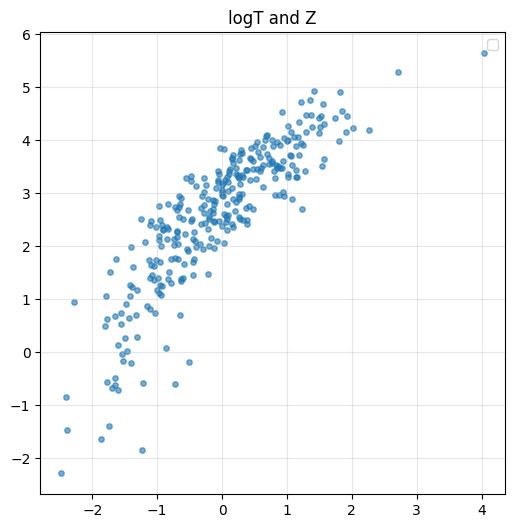

In [23]:
n_continuous=2
n_cat_covariates=0
d = n_continuous + n_cat_covariates
if d < 1:
    raise ValueError("At least one covariate is required.")

Y_latent = np.random.normal(0, 1, size=n)
## generate continuous covariates
covariates = []
for _ in range(n_continuous + n_cat_covariates):
    eps = np.random.normal(0, 1, size=n)
    # Z = rho * Y_latent + np.sqrt(1 - rho**2) * eps
    # Z = rho * np.exp(Y_latent) + np.sqrt(1 - rho**2) * eps
    Z = rho * (Y_latent) + np.sqrt(1 - rho**2) * eps
    covariates.append(Z)
covariates = np.column_stack(covariates)

treatment = np.random.binomial(1, 0.5, n)

# true event time
Y_true = -np.exp(beta_0 + theta * treatment) * np.log(1 - norm.cdf(Y_latent))

corr_Y_X = np.corrcoef(Y_true, covariates[:, 0])[0, 1]
print("Corr(Y, Z1): ", corr_Y_X)
plt.figure(figsize=(6, 6))

plt.scatter(
    covariates[:,0], np.log(Y_true),
    color='tab:blue', alpha=0.6,
    s=15
)

plt.title("logT and Z")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# rnrollment and interim info
inter_arrival_times = expon.rvs(scale=1 / enroll_per_month, size=n, random_state=seed)
enroll_time = np.cumsum(inter_arrival_times)
Y_plus_enroll = enroll_time + Y_true # calendar time of event
interim_time = np.sort(Y_plus_enroll)[n_interim - 1] # when the n_interim-th event happens
event_IA = (Y_plus_enroll <= interim_time).astype(int)
Y_ob_interim = np.minimum(Y_plus_enroll, interim_time) - enroll_time # aligned at zero time point
final_time = np.sort(Y_plus_enroll)[n_final - 1]
event_FA = (Y_plus_enroll <= final_time).astype(int)
Y_ob_final = np.minimum(Y_plus_enroll, final_time) - enroll_time


# intialize dataset
data_dict = {
    'Y_true': Y_true,
    'Y_ob_interim': Y_ob_interim,
    'event_IA': event_IA,
    'treatment': treatment,
    'Enroll': enroll_time,
    'event_GT': np.ones_like(treatment, dtype=int),
    "event_FA": event_FA,
    "Y_ob_final": Y_ob_final
}

# Add covariates
cov_idx = 0
if n_continuous > 0:
    for i in range(n_continuous):
        data_dict[f"Z_cont_{i + 1}"] = covariates[:, cov_idx]
        cov_idx += 1


data_organized = pd.DataFrame(data_dict)

# drop those who are not enrolled at interim
data_organized = data_organized[data_organized['Enroll'] < interim_time].reset_index(drop=True)
corr_Y_X_uncensored = data_organized.loc[data_organized['event_IA'] == 1,
                        ['Y_ob_interim', 'Z_cont_1']].corr().iloc[0, 1]

max_ob = data_organized.loc[data_organized['event_IA'] == 1, 'Y_ob_interim'].max()




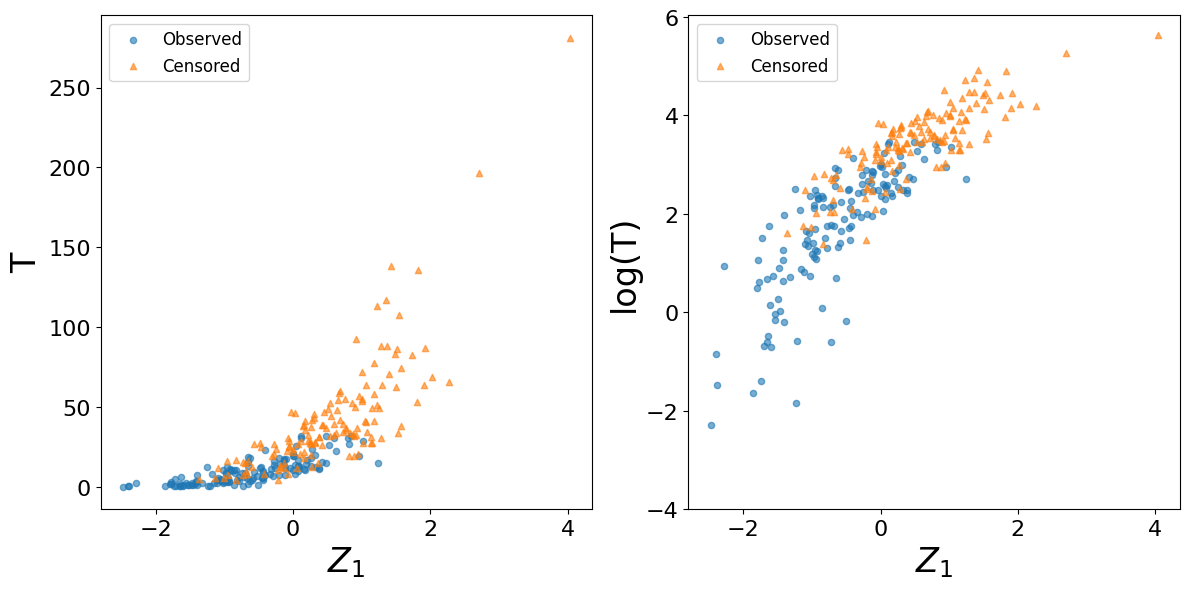

In [24]:
# generate scatter plots to visualize the relationship between Y_true and Z_cont_1, colored by event_IA status

# Masks
obs_mask = data_organized['event_IA'] == 1
cen_mask = data_organized['event_IA'] == 0
max_ob = data_organized.loc[obs_mask, 'Y_ob_interim'].max()

font_size = 24

# Data
Y_true = data_organized['Y_true']
covariates = data_organized[['Z_cont_1']].to_numpy()

# Create 1×2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

# Left panel : Y_true vs Z
ax = axes[0]
ax.scatter(
    covariates[obs_mask], Y_true[obs_mask],
    color='tab:blue', alpha=0.6, label='Observed', s=20
)
ax.scatter(
    covariates[cen_mask], Y_true[cen_mask],
    color='tab:orange', alpha=0.6, label='Censored', s=20, marker='^'
)
ax.set_xlabel(r"$Z_{1}$", fontsize=font_size)
ax.set_ylabel("T", fontsize=font_size)
ax.legend(fontsize=font_size-12, frameon=True)
ax.tick_params(axis='both', labelsize=font_size-8)
ax.set_yticks(np.arange(0, Y_true.max() + 1, 50)) 

# Right panel: log(Y_true) vs Z
ax = axes[1]
ax.scatter(
    covariates[obs_mask], np.log(Y_true[obs_mask]),
    color='tab:blue', alpha=0.6, label='Observed', s=20
)
ax.scatter(
    covariates[cen_mask], np.log(Y_true[cen_mask]),
    color='tab:orange', alpha=0.6, label='Censored', s=20, marker='^'
)
ax.set_xlabel(r"$Z_{1}$", fontsize=font_size)
ax.set_ylabel("log(T)", fontsize=font_size)
ax.legend(fontsize=font_size-12, frameon=True)
ax.tick_params(axis='both', labelsize=font_size-8)
ax.set_yticks(np.arange(-4, np.log(Y_true.max()) + 1, 2))
plt.tight_layout()
plt.show()

In [25]:
test_result = calculate_theta_paper(data_organized, 'Y_true', 'event_GT', 'treatment')
test_result = calculate_theta_paper(data_organized, 'Y_ob_final', 'event_FA', 'treatment')
print(test_result)

print(test_result['theta_hat'], theta)
print(test_result['test_result'])
print(test_result['theta_exact'])
print(test_result['test_result_logrank'])

{'theta_hat': 0.06018112880586824, 'L_stat': 0.4169470909944429, 'p_value': 0.6767171080684657, 'test_result': 0, 'theta_exact': 0.06034200303983785, 'L_exact': 0.41750400375629887, 'p_value_exact': 0.6763097963993356, 'test_result_exact': 0, 'logrank_stat': 0.17430959315254296, 'logrank_pval': 0.6763097963993328, 'test_result_logrank': 0, 'n_events': 192, 'U0': -2.8886941826816757, 'I0_exact': 47.872030048033984}
0.06018112880586824 -0.0
0
0.06034200303983785
0


In [26]:
theta_FA = calculate_theta_paper(
    data_organized, 'Y_ob_final', 'event_FA', 'treatment'
)
theta_FA = theta_FA['theta_hat']

theta_IA= calculate_theta_paper(
    data_organized, 'Y_ob_interim', 'event_IA', 'treatment'
)
theta_IA = theta_IA['theta_hat']



In [27]:
# AFT model fitting and prediction


n_dummy_cols = 0
continuous_cols = [col for col in data_organized.columns if col.startswith("Z_cont_")]
categorical_cols = [f"Z_cat_{i+1}" for i in range(n_dummy_cols)] if n_dummy_cols > 0 else []
covariate_cols = continuous_cols + categorical_cols


formula = "treatment + " + " + ".join(covariate_cols)



aft_model = WeibullAFTFitter()
aft_model.fit(
    data_organized[['Y_ob_interim', 'event_IA', 'treatment'] + covariate_cols],
    duration_col='Y_ob_interim',
    event_col='event_IA',
    formula=formula
    # ancillary=False
)
print("=== AFT model summary ===")
print(aft_model.summary.to_string())
print("=========================")
Euler_const = -digamma(1)

data_organized['Y_pred_aft'] = aft_model.predict_expectation(data_organized)

data_organized['Y_aft'] = np.where(
    data_organized['event_IA'] == 1,
    data_organized['Y_ob_interim'],
    data_organized['Y_pred_aft']
)

theta_AFT= calculate_theta_paper(
    data_organized, 'Y_aft', 'event_GT', 'treatment'
)
theta_AFT = theta_AFT['theta_hat']




=== AFT model summary ===
                       coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  cmp to          z             p   -log2(p)
param   covariate                                                                                                                                                     
lambda_ Intercept  3.157546  23.512834  0.075730        3.009119        3.305974            20.269534            27.275089     0.0  41.694969  0.000000e+00        inf
        treatment -0.104548   0.900732  0.083222       -0.267661        0.058565             0.765167             1.060314     0.0  -1.256250  2.090254e-01   2.258250
        Z_cont_1   0.723462   2.061558  0.081468        0.563787        0.883137             1.757314             2.418475     0.0   8.880266  6.670090e-19  60.378928
        Z_cont_2   0.692137   1.997980  0.079597        0.536129        0.848145             1.709377             2.335310     0.0   8.6954

In [28]:
CP(n_final, n_interim, alpha, theta_IA, theta_AFT)


0.0012007485255364214

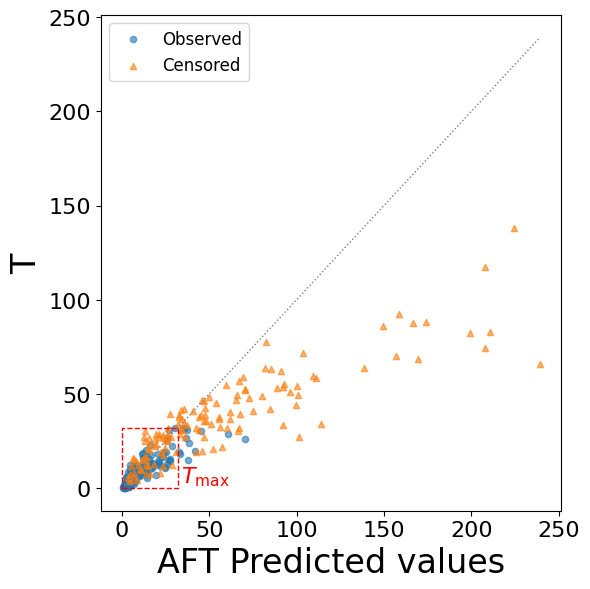

In [29]:
# plots of AFT predictions vs true times, colored by event_IA status

# Masks
obs_mask = data_organized['event_IA'] == 1
cen_mask = data_organized['event_IA'] == 0
max_ob = data_organized.loc[obs_mask, 'Y_ob_interim'].max()

data_plot = data_organized[
    (data_organized["Y_pred_aft"] <= 250) &
    (data_organized["Y_true"] <= 250)
].copy()

# Extract subsets
Y_true = data_plot["Y_true"]
Y_pred = data_plot["Y_pred_aft"]
obs_mask = data_plot["event_IA"] == 1
cen_mask = data_plot["event_IA"] == 0


font_size = 24

plt.figure(figsize=(6, 6))

# Scatter plots
plt.scatter(
    Y_pred[obs_mask], Y_true[obs_mask],
    color='tab:blue', alpha=0.6, label='Observed', s=20
)
plt.scatter(
    Y_pred[cen_mask], Y_true[cen_mask],
    color='tab:orange', alpha=0.6, label='Censored', s=20, marker='^' 
)

# Reference line (y = x)
lims = [min(Y_pred.min(), Y_true.min()), max(Y_pred.max(), Y_true.max())]
plt.plot(lims, lims, ':', linewidth=1, color='gray')

# A square box for T_max region ---
plt.plot([0, max_ob, max_ob, 0, 0],
         [0, 0, max_ob, max_ob, 0],
         color='red', linestyle='--', linewidth=1)

# Label for T_max
plt.text(max_ob * 1.05, 0,
         r"$T_{\max}$",
         color='red', fontsize=16, fontweight='bold',
         ha='left', va='bottom')

plt.xlabel("AFT Predicted values", fontsize=font_size)
plt.ylabel("T", fontsize=font_size)
plt.legend(fontsize=font_size-12, frameon=True)
plt.xticks([0, 50, 100, 150, 200, 250])
plt.yticks([0, 50, 100, 150, 200, 250])
plt.tick_params(axis='both', labelsize=font_size-8)
# plt.grid(alpha=0.3)
plt.tight_layout()


plt.show()


In [30]:
from operator import itemgetter

data_organized, theta_CQRNN, theta_CQRNN_maxob = \
    itemgetter('data_organized', 'theta_CQRNN', 'theta_CQRNN_maxob')(
        train_CQRNN_PPI(
    data_organized=data_organized,
    covariate_cols=covariate_cols,
    n_dummy_cols=n_dummy_cols
) 
)

CP(n_final, n_interim, alpha, theta_IA, theta_CQRNN)

0.011377979402728222

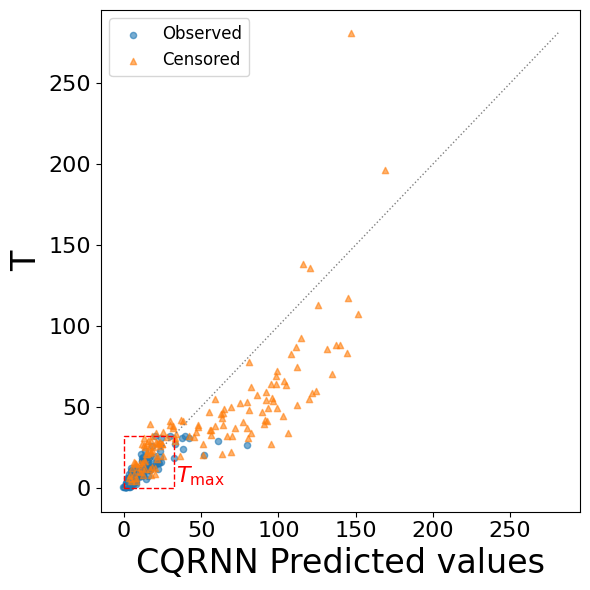

In [31]:
# plots of CQRNN predictions vs true times, colored by event_IA status

obs_mask = data_organized['event_IA'] == 1
cen_mask = data_organized['event_IA'] == 0
max_ob = data_organized.loc[obs_mask, 'Y_ob_interim'].max()

max_ob = data_organized.loc[obs_mask, 'Y_ob_interim'].max()
font_size = 24
Y_true = data_organized['Y_true']
Y_pred = data_organized['y_pred_median_np']

plt.figure(figsize=(6, 6))

plt.scatter(
    Y_pred[obs_mask], Y_true[obs_mask],
    color='tab:blue', alpha=0.6, label='Observed', s=20
)
plt.scatter(
    Y_pred[cen_mask], Y_true[cen_mask],
    color='tab:orange', alpha=0.6, label='Censored', s=20, marker='^' 
)

lims = [min(Y_pred.min(), Y_true.min()), max(Y_pred.max(), Y_true.max())]
plt.plot(lims, lims, ':', linewidth=1, color='gray')

plt.plot([0, max_ob, max_ob, 0, 0],
         [0, 0, max_ob, max_ob, 0],
         color='red', linestyle='--', linewidth=1)

plt.text(max_ob * 1.05, 0,
         r"$T_{\max}$",
         color='red', fontsize=16, fontweight='bold',
         ha='left', va='bottom')

plt.xlabel("CQRNN Predicted values", fontsize=font_size)
plt.ylabel("T", fontsize=font_size)
plt.legend(fontsize=font_size-12, frameon=True)
plt.xticks([0, 50, 100, 150, 200, 250])
plt.yticks([0, 50, 100, 150, 200, 250])
plt.tick_params(axis='both', labelsize=font_size-8)
# plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()
